STUDI KASUS 1



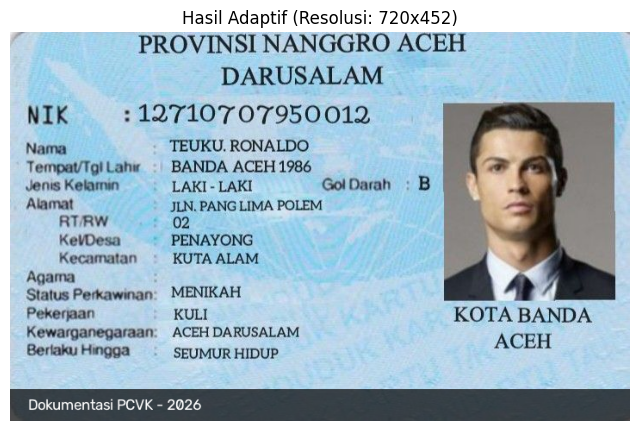




STUDI KASUS 2



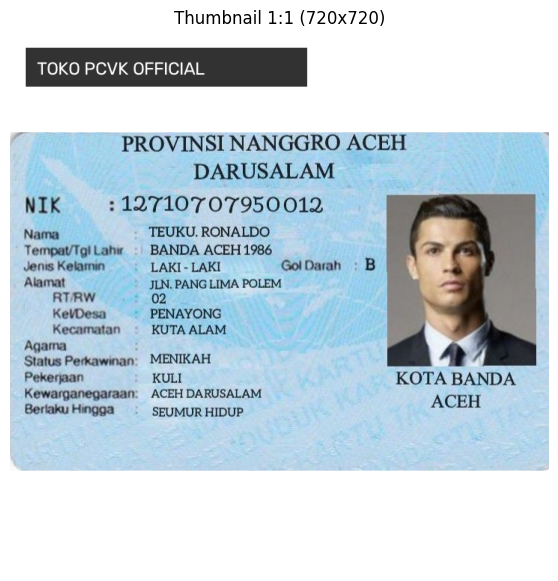

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img_path = 'ktp.jpg'

# STUDI KASUS 1
print("STUDI KASUS 1\n")

def tambahkan_label_adaptif(img_path, teks="Dokumentasi PCVK - 2026"):
    img = cv.imread(img_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Perhitungan adaptif sesuai jobsheet: tinggi bar = h // 12
    tinggi_bar = h // 12
    y_mulai_bar = h - tinggi_bar

    # 1. Gambar bar hitam transparan/pekat di bagian bawah
    img[y_mulai_bar:h, :] = (img[y_mulai_bar:h, :] * 0.3).astype(np.uint8) # semi-transparan / gelap

    # 2. Skala teks dan posisi adaptif
    font_scale = h / 750
    thickness = max(1, int(h / 350))
    posisi_x = int(w * 0.03)
    posisi_y = int(h - (tinggi_bar * 0.35))

    cv.putText(img, teks, (posisi_x, posisi_y), cv.FONT_HERSHEY_SIMPLEX,
               font_scale, (255, 255, 255), thickness, cv.LINE_AA)

    return img

# Contoh pemanggilan untuk 2 citra berbeda ukuran
hasil_1 = tambahkan_label_adaptif('ktp.jpg')
plt.figure(figsize=(8, 6))
plt.imshow(hasil_1)
plt.title(f"Hasil Adaptif (Resolusi: {hasil_1.shape[1]}x{hasil_1.shape[0]})")
plt.axis('off')
plt.show()

print("\n\n")

# STUDI KASUS 2
print("STUDI KASUS 2\n")

def buat_thumbnail_persegi(img_path, nama_toko="TOKO PCVK OFFICIAL"):
    img = cv.imread(img_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Sisi kanvas adalah ukuran terpanjang dari citra
    sisi_kanvas = max(h, w)

    # Buat kanvas putih persegi (sisi_kanvas x sisi_kanvas)
    kanvas = np.full((sisi_kanvas, sisi_kanvas, 3), 255, dtype=np.uint8)

    # Hitung offset agar gambar asli berada tepat di tengah (centering)
    offset_y = (sisi_kanvas - h) // 2
    offset_x = (sisi_kanvas - w) // 2

    # Pasang citra asli di tengah kanvas
    kanvas[offset_y:offset_y+h, offset_x:offset_x+w] = img

    # Tambahkan label/logo nama toko adaptif di pojok kiri atas
    font_scale = sisi_kanvas / 900
    thickness = max(1, int(sisi_kanvas / 450))

    # Box latar belakang untuk nama toko
    cv.rectangle(kanvas, (int(sisi_kanvas*0.03), int(sisi_kanvas*0.03)),
                 (int(sisi_kanvas*0.55), int(sisi_kanvas*0.1)), (50, 50, 50), -1)
    cv.putText(kanvas, nama_toko, (int(sisi_kanvas*0.05), int(sisi_kanvas*0.08)),
               cv.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness, cv.LINE_AA)

    return kanvas

# Eksekusi Thumbnail Persegi
hasil_thumbnail = buat_thumbnail_persegi('ktp.jpg')
plt.figure(figsize=(7, 7))
plt.imshow(hasil_thumbnail)
plt.title(f"Thumbnail 1:1 ({hasil_thumbnail.shape[1]}x{hasil_thumbnail.shape[0]})")
plt.axis('off')
plt.show()